# Pseudomode mapping for spin-boson model with underdamped Brownian bath

## Introduction

This notebook applies the approach of (Pleasance et al) to simulate the dynamics of the spin-boson model with underdamped spectral density. 

Further details on the spin-boson model are included in [pm_ohmic.ipynb](./notebooks/pm_ohmic.ipynb). 

The underdamped Brownian spectral density reads
\begin{equation*}
    J(\omega) = \frac{2\lambda^2\omega_0\Gamma\omega}{(\omega^2-\omega^2_0)^2 + \Gamma^2\omega^2},
\end{equation*}
where $\lambda$ measures the total system-bath coupling strength, $\Gamma$ is the bath width, and $\omega_0$ the resonance frequency. 

The bath correlation function (BCF) corresponding to this spectral density is given as
\begin{align*}
    C^B(t) &:= C_0(t) + M(t) \\
         &= \frac{\lambda^2\omega_0}{2\Omega}\bigg[\bigg(\coth\frac{\beta(\Omega-i\Gamma/2)}{2} + 1\bigg)e^{-i\Omega t} + \bigg(\coth\frac{\beta(\Omega+i\Gamma/2)}{2} - 1\bigg)e^{i\Omega t}\bigg]e^{-\Gamma|t|/2} + M(t),
\end{align*}
where $\beta = \frac{1}{k_BT}$ is the inverse bath temperature, $\Omega = \sqrt{\omega^2_0 - \frac{\Gamma^2}{4}}$, and 
\begin{equation*}
    M(t) = -i\frac{2}{\beta}\sum^{\infty}_{k=1}J(-i\nu_k)e^{-\nu_k |t|}
\end{equation*}
with Matsubara frequencies $\nu_k = \frac{2\pi k}{\beta}$ ($k\in\mathbb{N}$). 

Another useful quantity to consider is the bath noise spectrum 
\begin{equation*}
    \gamma(\omega) = 2\,{\rm Re}\int^{\infty}_0dt\,C^B(t)e^{i\omega t},
\end{equation*}
defined as the Fourier transform of $C^B(t)$, where $\gamma(\omega)\geq 0$ holds by definition.

In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
import matplotlib as mpl 
from numpy import linalg
from scipy.linalg import expm

# Import fitting library
from lmfit import minimize, Parameters

In [2]:
# Parameters (units of system energy eps)
eps = 1.0
T = 0.5
Gm = 0.1
om0 = 1
N_exp = 2
lmb = 0.5
Om = np.sqrt(om0 **2 - Gm **2 / 4)

## Fitting of bath correlation function

To extract the pseudomode parameters, we first need to fit $C^B(t)$ with a sum of $N$ complex exponentials
\begin{equation*}
    C^E(t) = -i\sum^N_{l=1}r_le^{-iz_lt}, \qquad t\geq0,
\end{equation*}
where $z_l$ and $r_l$ are both complex. 

It is also possible perform the same fitting in Fourier space using the target function
\begin{align*}
    \gamma'(\omega) &= 2\,{\rm Re}\int^{\infty}_0dt\,C^E(t)e^{i\omega t} \\
                    &= \sum^N_{l=1}\frac{ir_l}{\omega - z_l} - \frac{ir^*_l}{\omega - z^*_l},
\end{align*}
assuming $C^E(-t) = C^E(t)^*$. 

In [3]:
# Fit BCF with complex exponentials 
tlist = np.linspace(0, 50, 500)
omlist = np.linspace(-2, 2, 500) 

bcf = qt.UnderDampedEnvironment(T=T, lam=np.sqrt(2)*lmb, gamma=Gm, w0=om0).correlation_function(tlist)  # NB: scale lmb for consistency

spec = qt.UnderDampedEnvironment(T=T, lam=np.sqrt(2)*lmb, gamma=Gm, w0=om0).power_spectrum(omlist)

c0 = np.real(bcf[0])

def residuals(params, t, corr):
    #
    r1r = params['residue_real_1'].value
    r1i = params['residue_imag_1'].value
    r2r = params['residue_real_2'].value
    r2i = params['residue_imag_2'].value
    z1r = params['z_real_1'].value
    z1i = params['z_imag_1'].value
    z2r = params['z_real_2'].value
    z2i = params['z_imag_2'].value

    bcf_fit =  -1.0j*(r1r + 1.0j*r1i)*np.exp(-1.0j*(z1r-1.0j*z1i)*tlist) \
             +  -1.0j*(r2r + 1.0j*r2i)*np.exp(-1.0j*(z2r-1.0j*z2i)*tlist) 
            
    residual_corr = corr - bcf_fit
    
    return residual_corr.view(float)

params = Parameters() 
params.add('c0', value=c0, vary=False)
params.add('residue_real_1', value=1)
params.add('residue_imag_1', value=1)
params.add('residue_real_2',  expr='-residue_real_1')
params.add('residue_imag_2',  expr='c0-residue_imag_1')
params.add('z_real_1', value=Om)
params.add('z_real_2', expr='-z_real_1')  # fix to -xi_1 to obtain +ve PM decay rates - always positive?
params.add('z_imag_1', value=Gm, min=0)
params.add('z_imag_2', expr='z_imag_1')

result = minimize(residuals, params, method='leastsq', args=(tlist, bcf))

# Get fit parameters 
r1r = result.params['residue_real_1'].value
r1i = result.params['residue_imag_1'].value
r2r = result.params['residue_real_2'].value
r2i = result.params['residue_imag_2'].value
z1r = result.params['z_real_1'].value
z1i = result.params['z_imag_1'].value
z2r = result.params['z_real_2'].value
z2i = result.params['z_imag_2'].value


/Users/GraemePleasance/anaconda3/envs/qutip-env/lib/python3.12/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


In [4]:
# Extract coefficients and exponents of C^i = \sum_k c^i_k * exp(-v^i_k * t), where i = {real, imag} and C = C^R + 1j*C^I.
# Coefficients
ck = np.array([-1j*(r1r + 1.0j*r1i), -1j*(r2r + 1.0j*r2i)])
ck_real = list(0.5 * ck) + list(0.5 * np.conj(ck))
ck_imag = list(0.5j * np.conj(ck)) + list(-0.5j * ck)

# Exponents
vk = np.array([1j*(z1r-1j*z1i), 1j*(z2r-1j*z2i)])
vk_real = list(vk) + list(np.conj(vk))
vk_imag = list(np.conj(vk)) + list(vk)

bath_fit = qt.ExponentialBosonicEnvironment(ck_real=ck_real, ck_imag=ck_imag, vk_real=vk_real, vk_imag=vk_imag, combine=True) 

The error in the fit of the BCF and/or bath spectrum may be quantified through the measures
\begin{equation*}
    \Delta C(t) = |C^B(t) - C^E(t)|,
\end{equation*}
and 
\begin{equation*}
    \Delta\gamma(\omega) = |\gamma(\omega) - \gamma'(\omega)|.
\end{equation*}

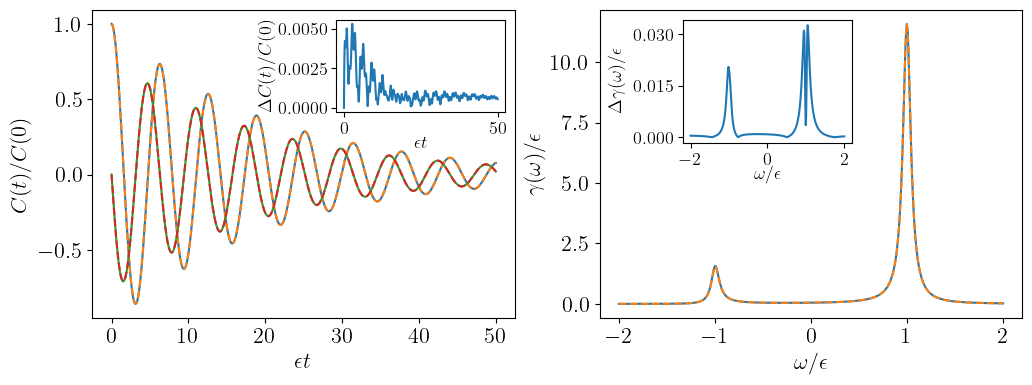

In [5]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Plots of physical and fitted BCFs
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['legend.fontsize'] = 14
mpl.rcParams['axes.titlesize'] = 15
mpl.rcParams['text.usetex'] = True

fig1, ax1 = plt.subplots(1,2, figsize=(12,4))

# BCF
ax1[0].plot(tlist, np.real(bcf) / c0, label=r'$\mathrm{Exact \, (real)}$')
ax1[0].plot(tlist, np.real(bath_fit.correlation_function(tlist)) / c0, linestyle='--', label=r'$\mathrm{Fit \, (real)}')
ax1[0].plot(tlist, np.imag(bcf) / c0, label=r'$\mathrm{Exact \, (imag)}$')
ax1[0].plot(tlist, np.imag(bath_fit.correlation_function(tlist)) / c0, linestyle='--', label=r'$\mathrm{Fit \, (imag)}')

ax1[0].set_xlabel(r'$\epsilon t$')
ax1[0].set_ylabel(r'$C(t)/C(0)$')

# Error - BCF
bcf_err = np.abs(bcf - bath_fit.correlation_function(tlist))

ax1_inset_left = inset_axes(ax1[0], width='40%', height='30%', loc='upper right')
ax1_inset_left.plot(tlist, bcf_err / c0)

ax1_inset_left.tick_params(labelsize=13)
ax1_inset_left.set_xticks([min(tlist), max(tlist)])
ax1_inset_left.set_yticks([0, 0.0025, 0.005])
ax1_inset_left.set_ylabel(r'$\Delta C(t) / C(0)$', fontsize=13, labelpad=1)
ax1_inset_left.set_xlabel(r'$\epsilon t$', fontsize=13, labelpad=-2)

# Spectrum
ax1[1].plot(omlist, spec, label=r'$\mathrm{Exact}$')
ax1[1].plot(omlist, bath_fit.power_spectrum(omlist), linestyle='--', label=r'$mathrm{Fit}$')

ax1[1].set_xlabel(r'$\omega/\epsilon$')
ax1[1].set_ylabel(r'$\gamma(\omega) / \epsilon$')

# Error - spectrum
spec_err = np.abs(spec - bath_fit.power_spectrum(omlist))

ax1_inset_right = inset_axes(ax1[1], width='40%', height='40%',
                             bbox_to_anchor=(-0.38, 0, 1, 1),  # (x, y, width, height)
                             bbox_transform=ax1[1].transAxes)

ax1_inset_right.plot(omlist, spec_err)

ax1_inset_right.tick_params(labelsize=13)
ax1_inset_right.set_yticks([0, 0.5 * np.round(np.max(spec_err),2), np.round(np.max(spec_err),2)])
ax1_inset_right.set_ylabel(r"$\Delta\gamma(\omega)/\epsilon$", fontsize=13, labelpad=5)
ax1_inset_right.set_xlabel(r'$\omega/\epsilon$', fontsize=13, labelpad=-2)

plt.show()

## Pseudomode parameters

Re-express fitted correlation function in the form 
\begin{equation}
C^E(t) = \boldsymbol{r}^Te^{-i\boldsymbol{\Lambda} t}\boldsymbol{r}, \qquad t\geq0,
\end{equation}
where $\boldsymbol{\Lambda} = {\rm diag}(z_1,...,z_N)$ and $\boldsymbol{r} = (\sqrt{-ir_1},...,\sqrt{-ir_N})^T$.

In [6]:
from pseudomodes.pure_dephasing import pm_parameters

rk = 1j * ck
zk = np.diag(-1j * vk)

g, xi, gm, info = pm_parameters(rk=rk, zk=zk, info=True)

print(info['all'])

g = 
 [-0.51774  0.24062]

xi = 
 [[-0.      -0.99972]
 [-0.99972 -0.     ]]

gm = 
 [0.0118  0.18715]


## PMME simulation: independent boson model (IBM)

To benchmark the PMME results, we consider an exactly solvable version of the spin-boson model - the independent boson model - where the system undergoes a purely dephasing dynamics ($\Delta =0$):
\begin{equation*}
 H = \frac{\epsilon}{2}\sigma_z + \sum_k\omega_ka^{\dagger}_ka_k + \sigma_z\otimes B.
\end{equation*}
The system Bloch vector in this case evolves according to
\begin{equation*}
    \begin{pmatrix}
    \langle \sigma_x(t)\rangle \\ 
    \langle \sigma_y(t)\rangle \\ 
    \langle \sigma_z(t)\rangle
    \end{pmatrix}
    =
    \begin{pmatrix}
    2\,{\rm Re}[e^{i\epsilon t + \phi(t)}\rho_{10}] \\ 
    2\,{\rm Im}[e^{i\epsilon t + \phi(t)}\rho_{10}]  \\ 
    \langle \sigma_z(0)\rangle
    \end{pmatrix},
\end{equation*}
where $\rho_{10} = \langle 1|\rho_S(t)|0\rangle$, and 
\begin{equation*}
    \phi(t) = -\frac{4}{\pi}\int^{\infty}_0d\omega\frac{J(\omega)}{\omega^2}\coth\left(\frac{\beta\omega}{2}\right)(1-\cos\omega t).
\end{equation*}

In [7]:
# Constuct PMME
tlist_pm = np.linspace(0, 25, 500)

# Local PM dims
N1, N2 = 16, 16
Nlist = [N1, N2]

# Initial system + PM state
init_state = qt.tensor([qt.ket2dm((qt.basis(2) + qt.basis(2,1)).unit())] + [qt.fock_dm(N) for N in Nlist])

sigx = qt.tensor([qt.sigmax()] + [qt.identity(N) for N in Nlist])
sigy = qt.tensor([qt.sigmay()] + [qt.identity(N) for N in Nlist])
sigz = qt.tensor([qt.sigmaz()] + [qt.identity(N) for N in Nlist])

b_ops = []
for n in range(len(Nlist)): 
  b_ops.append(qt.tensor([qt.identity(2)] + [qt.destroy(N) if n == idx else qt.identity(N) for idx, N in enumerate(Nlist)]))

# Hamiltonian
H_S = 1/2 * eps * sigz
H_E = 0 
H_I = 0
for i in range(len(b_ops)):
    H_I += g[i] * sigz * (b_ops[i] + b_ops[i].dag())
    for j in range(len(b_ops)):
        H_E += xi[i][j] * b_ops[i].dag() * b_ops[j] 

H = H_S + H_E + H_I

# Construct GKSL part of dissipator
L_sys_pm = qt.liouvillian(H=H, c_ops=[np.sqrt(dr) * b_ops[i] if dr > 0 else 0 * b_ops[i] for i, dr in enumerate(np.diag(gm))])

# Add non-GKSL part (negative decay rates)
for i, dr in enumerate(np.diag(gm)):
    if dr < 0:
        L_sys_pm -= qt.lindblad_dissipator(a=np.sqrt(np.abs(dr)) * b_ops[i])

In [8]:
# Solve PMME
result = qt.mesolve(L_sys_pm, init_state, tlist_pm, e_ops=[sigx, sigy] + [op.dag() * op for op in b_ops], options={'progress_bar': True})

10.0%. Run time:   1.03s. Est. time left: 00:00:00:09
20.0%. Run time:   3.36s. Est. time left: 00:00:00:13
30.1%. Run time:   5.96s. Est. time left: 00:00:00:13
40.1%. Run time:   8.84s. Est. time left: 00:00:00:13
50.1%. Run time:  11.41s. Est. time left: 00:00:00:11
60.1%. Run time:  13.96s. Est. time left: 00:00:00:09
70.1%. Run time:  16.50s. Est. time left: 00:00:00:07
80.2%. Run time:  19.12s. Est. time left: 00:00:00:04
90.2%. Run time:  21.66s. Est. time left: 00:00:00:02
100.0%. Run time:  24.16s. Est. time left: 00:00:00:00
Total run time:  24.16s


### Benchmarking

Relative error for each Bloch component $\langle\sigma_i(t)\rangle$,
\begin{equation*}
    \varepsilon_i = 100 \times \frac{|\Delta\langle\sigma_i(t)\rangle|}{|\langle\sigma_i(t)\rangle|},
\end{equation*}
where $\Delta\langle\sigma_i(t)\rangle = \langle\sigma_i(t)\rangle - {\rm Tr}[(\sigma_i\otimes\mathbb{I}_E)\rho(t)]$.

/Users/GraemePleasance/Documents/PM theory 2/Python/pseudomodes/pure_dephasing.py:256: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integral = lambda t: quad(lambda w: dephase_integrand(w, t, T, sd_type=sd_type, coup=kwargs['coup'], width=kwargs['width'], w_res=kwargs['w_res']), 0, np.inf)[0]
/var/folders/cl/lf0z7k5n0p91rtvfr_fc1hr00000gn/T/ipykernel_31390/4183434989.py:23: RuntimeWarning: invalid value encountered in divide
  ax2[1].plot(tlist_pm, 100 * np.abs(evolved_bloch_vector[1] - result.expect[1]) / (np.abs(evolved_bloch_vector[1])), label=r'$i=y$')


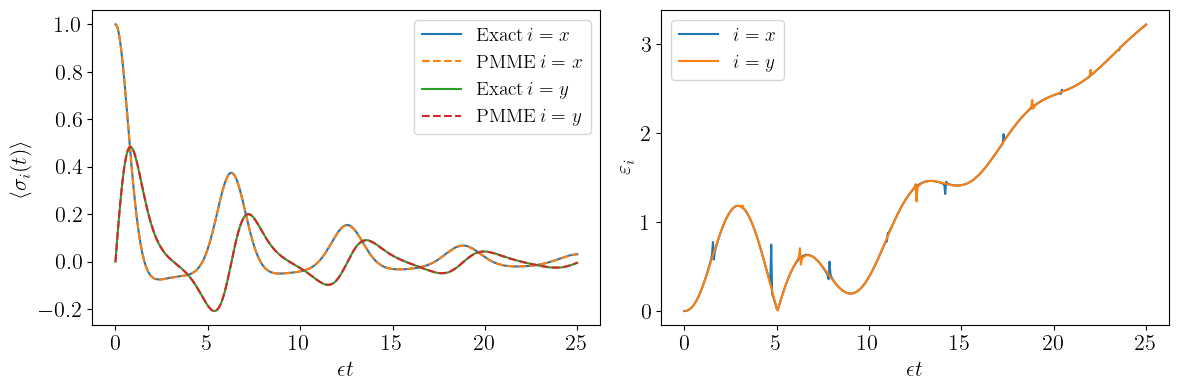

In [9]:
from pseudomodes.pure_dephasing import dephase_exp

# Initial Bloch vector
init_tls_state = init_state.ptrace(0)

bloch_vector = np.array([qt.expect(qt.sigmax(), init_tls_state), qt.expect(qt.sigmay(), init_tls_state), qt.expect(qt.sigmaz(), init_tls_state)])

# Compute time-evoled Bloch vector (decoherence function)
evolved_bloch_vector = dephase_exp(tlist_pm, bloch_vector, eps=eps, T=T, sd_type='Underdamped', coup=lmb, width=Gm, w_res=om0)

fig2, ax2 = plt.subplots(1,2, figsize=(12,4))

ax2[0].plot(tlist_pm, evolved_bloch_vector[0], label=r'$\mathrm{Exact} \, i=x$')
ax2[0].plot(tlist_pm, result.expect[0], linestyle='--', label=r'$\mathrm{PMME} \, i=x$')
ax2[0].plot(tlist_pm, evolved_bloch_vector[1], label=r'$\mathrm{Exact} \, i=y$')
ax2[0].plot(tlist_pm, result.expect[1], linestyle='--', label=r'$\mathrm{PMME} \, i=y$')

ax2[0].set_xlabel(r'$\epsilon t$')
ax2[0].set_ylabel(r'$\langle \sigma_i(t)\rangle$')
ax2[0].legend()

ax2[1].plot(tlist_pm, 100 * np.abs(evolved_bloch_vector[0] - result.expect[0]) / (np.abs(evolved_bloch_vector[0])), label=r'$i=x$')
ax2[1].plot(tlist_pm, 100 * np.abs(evolved_bloch_vector[1] - result.expect[1]) / (np.abs(evolved_bloch_vector[1])), label=r'$i=y$')

ax2[1].set_xlabel(r'$\epsilon t$')
ax2[1].set_ylabel(r'$\varepsilon_i$')
ax2[1].legend()

fig2.tight_layout()

plt.show()

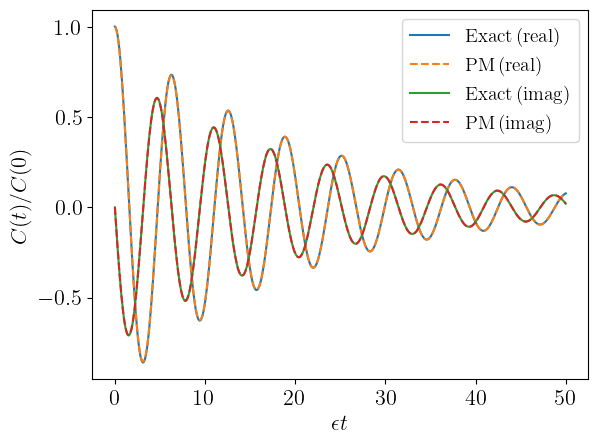

In [11]:
from pseudomodes.pure_dephasing import bcf_ud, bcf_pm

# Additional checks
fig3, ax3 = plt.subplots()

# PM correlation function
ax3.plot(tlist, np.real(bcf_ud(tlist, T=T, coup=lmb, width=Gm, w_res=om0, Nk=100)) / c0, label=r'$\mathrm{Exact \, (real)}$')
ax3.plot(tlist, np.real(bcf_pm(tlist, g, xi, gm)) / c0, linestyle='--', label=r'$\mathrm{PM \, (real)}$')
ax3.plot(tlist, np.imag(bcf_ud(tlist, T=T, coup=lmb, width=Gm, w_res=om0, Nk=100)) / c0, label=r'$\mathrm{Exact \, (imag)}$')
ax3.plot(tlist, np.imag(bcf_pm(tlist, g, xi, gm)) / c0, linestyle='--', label=r'$\mathrm{PM \, (imag)}$')

ax3.set_xlabel(r'$\epsilon t$')
ax3.set_ylabel(r'$C(t) / C(0)$')
ax3.legend()

plt.show()

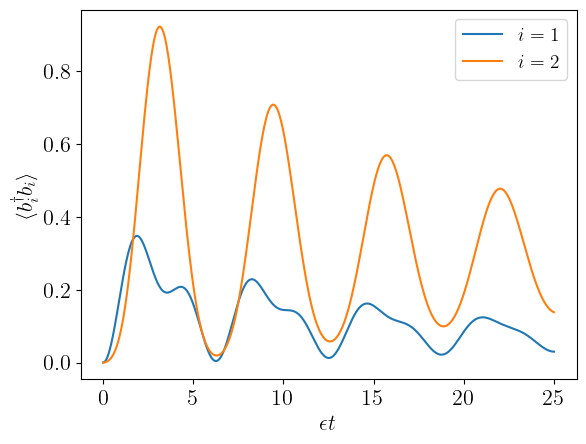

In [13]:
# Pseudomode populations - are guaranteed positive if PMME is in GKSL form
fig4, ax4 = plt.subplots()

for b in range(len(b_ops)):
    ax4.plot(tlist_pm, result.expect[b+2], label=r'$i={}$'.format(b+1))

ax4.set_xlabel(r'$\epsilon t$')
ax4.set_ylabel(r'$\langle b^{\dagger}_ib_i\rangle $')
ax4.legend()

plt.show()

In [ ]:
## Save simulation data